# A Brief matplotlib API Primer

`matplotlib` is the low-level plotting library that pandas' `.plot()` and `seaborn` are both built on top of. Most day-to-day plotting can be done through those higher-level interfaces (see [09.2](./09_02_Plotting_with_pandas_and_seaborn.ipynb)) — this primer covers the underlying `matplotlib` object model (figures, axes, ticks, legends, annotations) for when you need finer-grained control.

With matplotlib, we use the following import convention:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In classic Jupyter Notebook, running `%matplotlib notebook` enables an interactive backend (in JupyterLab this requires the `ipympl` package and `%matplotlib widget` instead). This notebook doesn't use either — plots render as static inline images, which is the default and is fine for most exploratory work. Let's try creating a simple plot.

In [2]:
data = np.arange(10)

data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

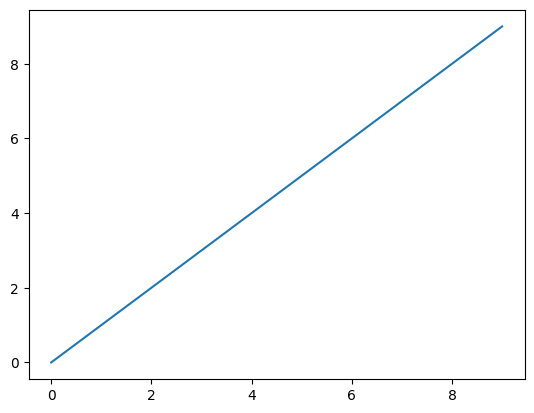

In [3]:
plt.plot(data)

While libraries like `seaborn` and pandas' built-in plotting functions handle many of the mundane details of making plots, if you want to customize them beyond the options they provide, you'll need to learn a bit of the `matplotlib` API.

## Figures and Subplots

Plots in `matplotlib` reside within a `Figure` object. Create a new figure with `plt.figure`:

In [4]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

`plt.figure` has a number of options; notably, `figsize` guarantees the figure has a certain size and aspect ratio when saved to disk.

You can't make a plot with a blank figure — you have to create one or more subplots using `add_subplot`:

In [5]:
ax1 = fig.add_subplot(2, 2, 1)

This means that the figure should be `2 x 2` (so up to four plots in total), and we're selecting the first of four subplots (numbered from 1). If you create the next two subplots, you'll end up with a visualization that looks like:

In [6]:
ax2 = fig.add_subplot(2, 2, 2)

ax3 = fig.add_subplot(2, 2, 3)

Running all the commands in the same cell:

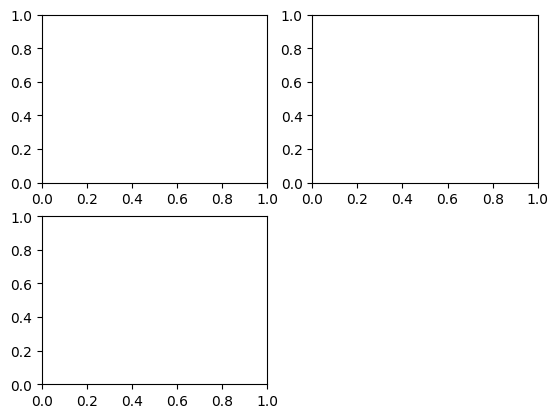

In [7]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)


These plot axis objects have various methods that create different types of plots, and it is preferred to use the axis methods over the top-level plotting functions like `plt.plot`. For example, we could make a line plot with the `plot` method. 

In [8]:
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

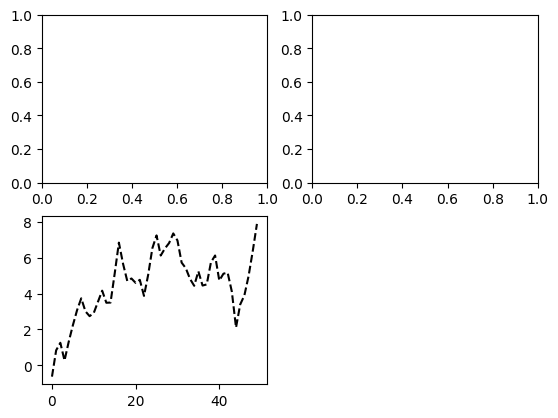

In [9]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

You may notice output like `<matplotlib.lines.Line2D at ...>` when you run this. `matplotlib` returns objects that reference the plot subcomponent that was just added. Most of the time you can safely ignore this output, or put a semicolon at the end of the line to suppress it.

The additional options instruct `matplotlib` to plot a black dashed line. The objects returned by `fig.add_subplot` are `AxesSubplot` objects — you can plot directly on any of the other empty subplots by calling each one's own instance methods.

In [10]:
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3);
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30));

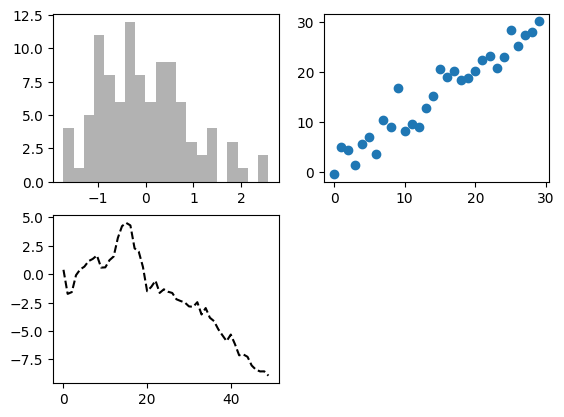

In [11]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3);
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30));
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

### Adjusting the spacing around subplots

By default, `matplotlib` leaves a certain amount of padding around the outside of the subplots and between subplots. This spacing is specified relative to the height and width of the plot, so if you resize the plot — programmatically or manually via the GUI window — it adjusts dynamically. Change the spacing using the `subplots_adjust` method on `Figure` objects:

```python
subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
```

`wspace` and `hspace` control the percent of the figure width and figure height, respectively, used as spacing between subplots. Here's a small example where the spacing is shrunk all the way to zero:

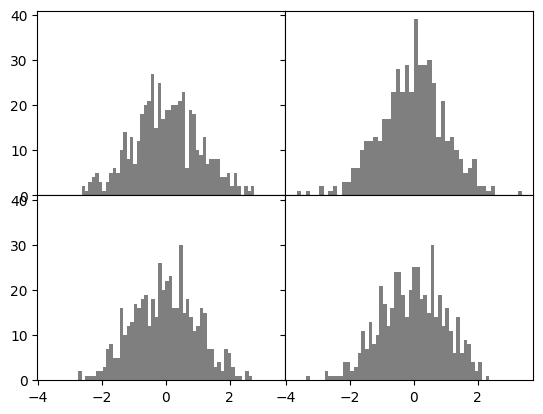

In [12]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50, color="black", alpha=0.5)
fig.subplots_adjust(wspace=0, hspace=0)

You may notice that the axis labels overlap — `matplotlib` doesn't check whether labels overlap, so in a case like this you'd need to fix them yourself by specifying explicit tick locations and tick labels (covered below).

## Colors, Markers, and Line Styles

matplotlib's line `plot` function accepts arrays of x and y coordinates and optional color styling options. For example, to plot `x` versus `y` with green dashes, you would execute something like this:

```python
ax.plot(x, y, linestyle="--", color="green")
```

A number of color names are provided for commonly used colors, but you can use any color on the spectrum by specifying its hex code, prefixed with `#` (e.g., `"#CECECE"`). You can see some of the supported line styles by looking at the docstring for `plt.plot`. A more comprehensive reference is available in the online documentation.

Line plots can additionally have *markers* to highlight the actual data points. Since matplotlib's `plot` function creates a continuous line plot, interpolating between points, it can occasionally be unclear where the points lie. The marker can be supplied as an additional styling option.

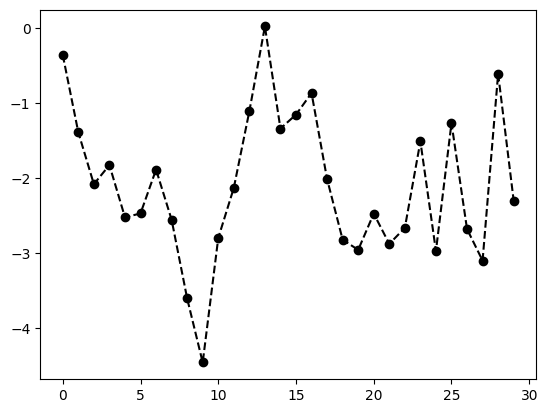

In [13]:
fig = plt.figure()

ax = fig.add_subplot()

ax.plot(np.random.standard_normal(30).cumsum(), color="black", linestyle="dashed", marker="o");

For line plots, you will notice that subsequent points are linearly interpolated by default. This can be altered with the `drawstyle` option:



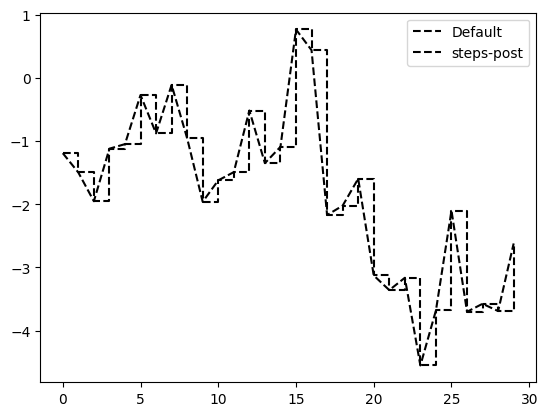

In [14]:
fig = plt.figure()

ax = fig.add_subplot()

data = np.random.standard_normal(30).cumsum()

ax.plot(data, color="black", linestyle="dashed", label="Default");
ax.plot(data, color="black", linestyle="dashed", drawstyle="steps-post", label="steps-post");
ax.legend()

## Ticks, Labels, and Legends

Most kinds of plot decorations can be accessed through methods on matplotlib's axes objects. This includes methods like `xlim`, `xticks`, and `xticklabels`, which control the plot range, tick locations, and tick labels, respectively. They can be used in two ways:
- Called with no arguments, they return the current parameter value (e.g., `ax.get_xlim()` returns the current `x`-axis plotting range)
- Called with parameters, they set the parameter value (e.g., `ax.set_xlim([0, 10])` sets the `x`-axis range to 0–10)

All such methods act on the active or most recently created `AxesSubplot`. Each corresponds to a pair of `get_`/`set_` methods on the subplot object itself — for `xlim`, these are `ax.get_xlim` and `ax.set_xlim`.

### Setting the title, axis labels, ticks, and tick labels

To illustrate customizing the axes, here's a simple figure and plot of a random walk:

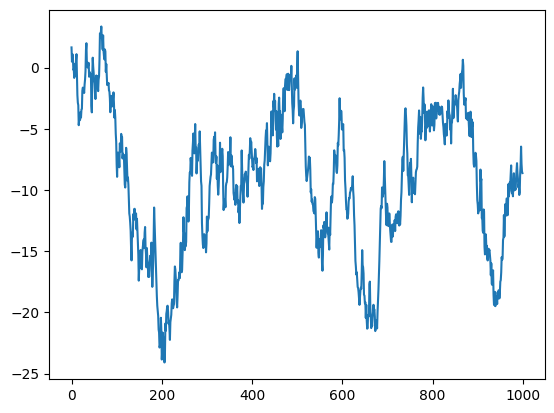

In [15]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum())

To change the `x`-axis ticks, it's easiest to use `set_xticks` and `set_xticklabels`. The former instructs matplotlib where to place the ticks along the data range; by default these locations are also used as the labels. But we can set any other value as the labels using `set_xticklabels`:

In [16]:
ticks = ax.set_xticks([0, 250, 500, 750, 1000])

labels = ax.set_xticklabels(["one", "two", "three", "four", "five"], rotation=30, fontsize=8)

The `rotation` option sets the x tick labels at a 30-degree rotation. Lastly, `set_xlabel` gives a name to the `x`-axis, and `set_title` sets the subplot title.

In [17]:
ax.set_xlabel("Stages")


Text(0.5, 4.444444444444445, 'Stages')

In [18]:
ax.set_title("My first matplotlib plot")

Text(0.5, 1.0, 'My first matplotlib plot')

Text(0.5, 1.0, 'My first matplotlib plot')

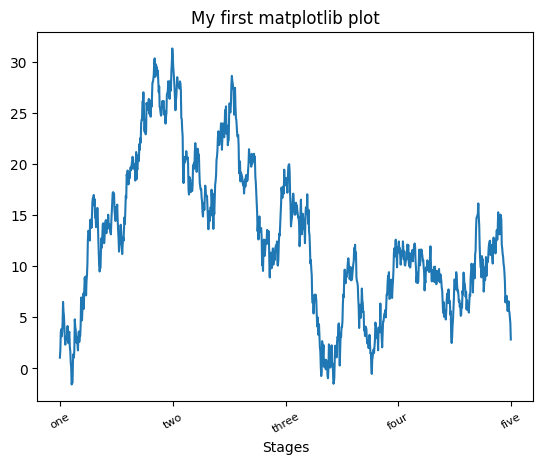

In [19]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])

labels = ax.set_xticklabels(["one", "two", "three", "four", "five"], rotation=30, fontsize=8)
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot")

Modifying the `y`-axis consists of the same process, substituting `y` for `x` in this example. The axes class also has a `set` method that allows batch-setting of plot properties in one call. From the prior example, we could have also written:

```python
ax.set(title="My first matplotlib plot", xlabel="Stages")
```

### Adding Legends

Legends are another critical element for identifying plot elements. There are a couple of ways to add one. The easiest is to pass the `label` argument when adding each piece of the plot, then call `ax.legend()`:

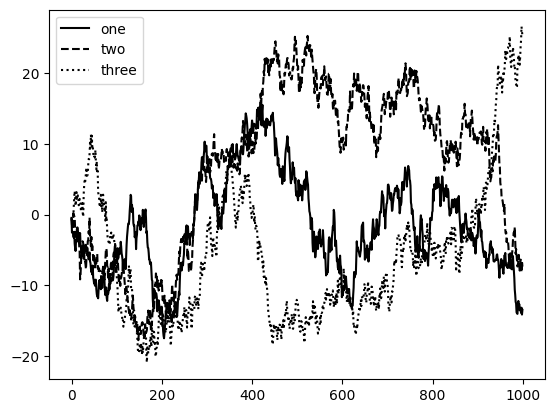

In [20]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum(), color="black", label="one");
ax.plot(np.random.standard_normal(1000).cumsum(), color="black", linestyle="dashed", label="two");
ax.plot(np.random.standard_normal(1000).cumsum(), color="black", linestyle="dotted", label="three");
ax.legend();

The `legend` method has several other choices for the `loc` argument — see the docstring (`ax.legend?` in Jupyter, or `help(ax.legend)`) for the full list.

`loc` tells `matplotlib` where to place the legend. The default is `"best"`, which tries to choose the location that's most out of the way of the data. To exclude one or more elements from the legend, either don't pass a `label` for that call, or pass the special sentinel value:

```python
label="_nolegend_"
```

## Annotations and Drawing on a Subplot

In addition to the standard plot types, you may want to draw your own plot annotations — text, arrows, or other shapes. Add annotations and text using the `text`, `arrow`, and `annotate` functions. `text` draws text at given coordinates (`x, y`) on the plot with optional custom styling:

```python
ax.text(x, y, "Hello, World!", family="monospace", fontsize=10)
```

Annotations can combine text and arrows arranged appropriately. As an example, let's plot the closing S&P 500 index price since 2007 and annotate it with some of the important dates from the 2008–2009 financial crisis:

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

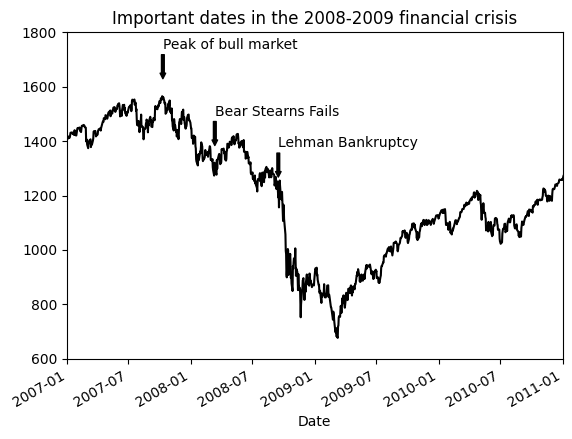

In [21]:
from datetime import datetime
import pandas as pd

fig, ax = plt.subplots()

data = pd.read_csv("/Users/bmart231/DS/examples/spx.csv", index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                 headlength=4),
                horizontalalignment="left", verticalalignment="top")

# Zoom in on 2007-2010
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008-2009 financial crisis")

A couple of important points to highlight in this plot: `ax.annotate` draws labels at the indicated x and y coordinates. `set_xlim` and `set_ylim` manually set the start and end boundaries for the plot rather than relying on matplotlib's default. Lastly, `ax.set_title` adds a main title to the plot.

Drawing shapes takes a bit more care — matplotlib has objects that represent many common shapes, referred to as *patches*. Some of these, like `Rectangle` and `Circle`, are accessible directly from `matplotlib.pyplot`, but the full set lives in `matplotlib.patches`.

To add a shape to a plot, create the patch object and add it to a subplot `ax` by passing the patch to `ax.add_patch`:

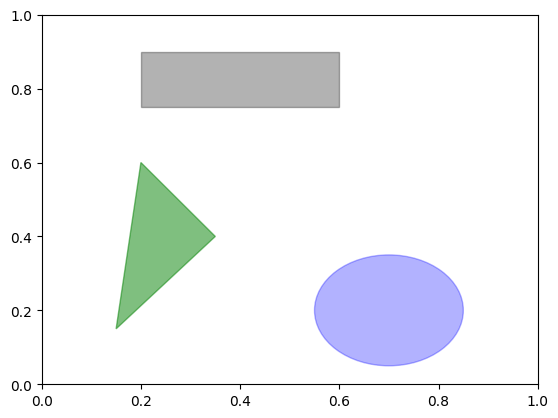

In [22]:
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]], color="green", alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

## Saving Plots to File

Save the active figure to a file using the figure object's `savefig` instance method. For example, to save an SVG version of a figure:

```python
fig.savefig("figpath.svg")
```

The file type is inferred from the extension — use `.pdf` instead and you'd get a PDF. One important option for polishing graphs is `dpi`, which controls the dots-per-inch resolution:

```python
fig.savefig("figpath.png", dpi=400)
```

`bbox_inches="tight"` is another commonly used option — it trims the whitespace around the figure:

```python
fig.savefig("figpath.png", dpi=400, bbox_inches="tight")
```

`savefig` doesn't have to write to disk — it can also write to any file-like object, such as a `BytesIO`, which is handy for serving images dynamically (e.g., from a web application) without touching the filesystem.

## matplotlib Configuration

matplotlib comes configured with color schemes and defaults geared primarily toward preparing figures for publication. Fortunately, nearly all of the default behavior can be customized via global parameters governing figure size, subplot spacing, colors, font sizes, grid styles, and more. One way to modify the configuration programmatically is the `rc` method — for example, to set the global default figure size to `10 x 10`:

```python
plt.rc("figure", figsize=(10, 10))
```

All current configuration settings live in the `plt.rcParams` dictionary and can be restored to their defaults with `plt.rcdefaults()`.

The first argument to `rc` is the component to customize, such as `"figure"`, `"axes"`, `"xtick"`, `"ytick"`, `"grid"`, `"legend"`, or many others, followed by a sequence of keyword arguments for the new parameters. A convenient way to write down the options is as a dictionary:

```python
plt.rc("font", family="monospace", weight="bold", size=8)
```

In [23]:
# check a current default, change it, then restore it
print(plt.rcParams["figure.figsize"])

plt.rc("figure", figsize=(10, 10))
print(plt.rcParams["figure.figsize"])

plt.rcdefaults()
print(plt.rcParams["figure.figsize"])

[6.4, 4.8]
[10.0, 10.0]
[6.4, 4.8]


## Quick Reference

**Object model:** `Figure` (the whole window/canvas) contains one or more `Axes` (a single subplot). Almost everything below is a method on an `Axes` instance (`ax`), not on `plt` directly — prefer `ax.<method>` over top-level `plt.<function>` once you have an axes object.

| Task | Method |
|---|---|
| Create a figure | `fig = plt.figure()` or `fig, ax = plt.subplots(nrows, ncols)` |
| Add a subplot to a figure | `fig.add_subplot(nrows, ncols, index)` |
| Plot a line | `ax.plot(data, color=, linestyle=, marker=, drawstyle=, label=)` |
| Plot a histogram | `ax.hist(data, bins=, color=, alpha=)` |
| Plot a scatter | `ax.scatter(x, y)` |
| Adjust spacing between subplots | `fig.subplots_adjust(wspace=, hspace=)` |
| Get / set axis limits | `ax.get_xlim()` / `ax.set_xlim([lo, hi])` (same pattern for `y`) |
| Get / set tick positions | `ax.get_xticks()` / `ax.set_xticks([...])` |
| Get / set tick labels | `ax.get_xticklabels()` / `ax.set_xticklabels([...], rotation=, fontsize=)` |
| Axis label / title (individually) | `ax.set_xlabel("...")` / `ax.set_title("...")` |
| Axis label / title (batched) | `ax.set(xlabel="...", title="...")` |
| Show the legend (requires `label=` on each plot call) | `ax.legend(loc="best")` |
| Draw free text / an arrow annotation | `ax.text(x, y, "...")` / `ax.annotate("...", xy=, xytext=, arrowprops=)` |
| Draw a shape | create a `plt.Rectangle`/`Circle`/`Polygon`, then `ax.add_patch(shape)` |
| Save to file | `fig.savefig("path.png", dpi=400, bbox_inches="tight")` |
| Change global defaults | `plt.rc("figure", figsize=(10, 10))`, inspect via `plt.rcParams`, reset via `plt.rcdefaults()` |
| Suppress the `<matplotlib.lines.Line2D ...>` echo | end the line with `;` |

**Common pitfalls:**
- `ax.legend()` — passing `label=` to `.plot()` calls doesn't draw a legend by itself; you must still call `.legend()`.
- Reusing an old `fig`/`ax` variable from an earlier cell instead of creating a fresh one with `plt.figure()`/`plt.subplots()` draws on top of (or alongside) whatever is already on that figure.
- `linestyle="-"` is solid; `"--"` is dashed, `":"` is dotted, `"-."` is dash-dot.
- The legend's "exclude from legend" sentinel is exactly `"_nolegend_"` — misspelling it just gives you a garbled legend entry instead of hiding it.